# sin함수 추론하기

In [15]:
import math
import torch
import matplotlib.pyplot as plt

In [24]:
# 학습용 데이터
x = torch.linspace(-math.pi, math.pi, 1000)

# 정답
y = torch.sin(x)


In [25]:
# 3차 다항식 정의
# f(x) = ax**3 + bx**2 + cx + d
# 초기화
a=torch.randn(())
b=torch.randn(())
c=torch.randn(())
d=torch.randn(())

y_random = a*x**3 + b*x**2 + c*x + d

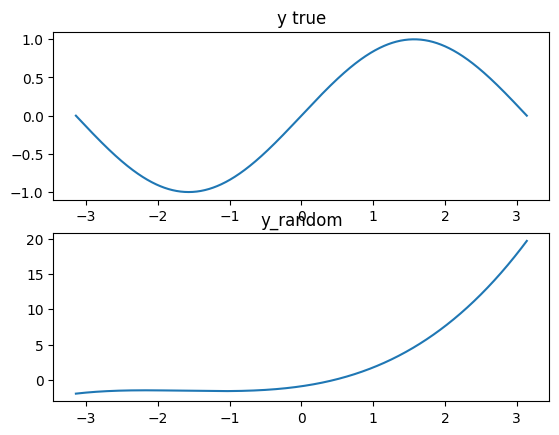

In [26]:
# sin 함수 그려보기
# 1. 실제값 출력
plt.subplot(2,1,1)
plt.title('y true')
plt.plot(x,y)

# 2. 임의의 가중치로 만든 예측용 값으로 시각화
plt.subplot(2,1,2)
plt.title('y_random')
plt.plot(x,y_random)

plt.show()


##### 학습

- _2. 손실함수 MSE_

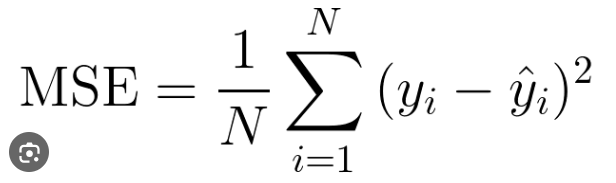


- _3.1. 기울기의 미분값_

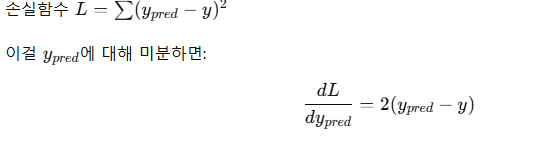

- _3.2 파라미터별 기울기 계산_

loss는 파라미터들과 직접 연관이 없다. 다만, 다음과 같은 연쇄구조를 가진다. <br>
    - a,b,c,d - y_pred -> loss <br>
    - loss = (y_pred - loss)
우리는 loss에 영향을 미치는 a의 변화량을 알고싶음.  so,
> `D-loss` / `D-a` = `(D-loss)`/`(D-y_pred)` * `(D-y_pred)`/`(D_a)`  <br>
>> D-loss / D-y_pred = 2x(y_pred - y)  <br>
>> D_y_pred / D-a = x^3 <br>

> `D-loss` / `D-b` <br>
> `D-loss` / `D-c` <br>
> `D-loss` / `D-d` <br>

---


| 단계         | 코드                                   | 의미                    |
| ---------- | ------------------------------------ | --------------------- |
| 순전파        | `y_pred = a*x**3 + b*x**2 + c*x + d` | 예측 계산                 |
| 손실 계산      | `loss = (y_pred - y).pow(2).sum()`   | 오차 측정                 |
| 미분(기울기 계산) | `grad_y_pred = 2*(y_pred - y)`       | 예측값에 대한 손실의 기울기       |
| 파라미터별 기울기  | `grad_a, grad_b, grad_c, grad_d`     | 각 파라미터의 변화율 계산        |
| 업데이트       | `a -= lr * grad_a` 등                 | 손실이 줄어드는 방향으로 파라미터 수정 |



epoch: 1 | loss:0.004427051637321711
epoch: 101 | loss:0.004427049309015274
epoch: 201 | loss:0.0044270469807088375
epoch: 301 | loss:0.004427045118063688
epoch: 401 | loss:0.004427043721079826
epoch: 501 | loss:0.004427042324095964
epoch: 601 | loss:0.00442704139277339
epoch: 701 | loss:0.0044270409271121025
epoch: 801 | loss:0.004427039530128241
epoch: 901 | loss:0.004427039530128241
epoch: 1001 | loss:0.004427039064466953
epoch: 1101 | loss:0.004427038133144379
epoch: 1201 | loss:0.004427038133144379
epoch: 1301 | loss:0.004427037667483091
epoch: 1401 | loss:0.004427037201821804
epoch: 1501 | loss:0.004427037201821804
epoch: 1601 | loss:0.004427036736160517
epoch: 1701 | loss:0.004427037201821804
epoch: 1801 | loss:0.004427036736160517
epoch: 1901 | loss:0.004427036736160517


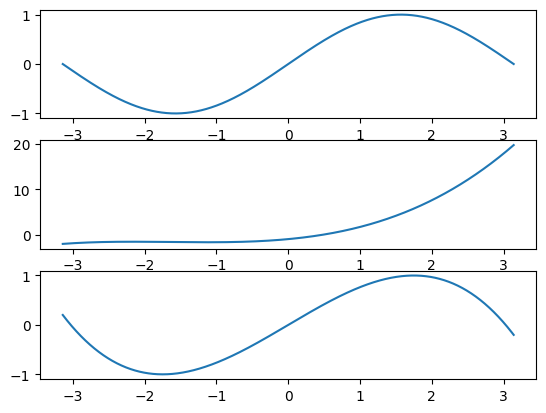

In [ ]:
# 파라미터 정의
learning_rate = 1e-6

for epoch in range(2000): #a,b,c,d를 2000번 업데이트
    # 1. forward (순전파: 처음 정상적인 학습)
    y_pred = a*x**3 + b*x**2 + c*x + d #모델
    
    # 2. 손실 정의 MSE(평균제곱오차)
    #   - 오차를 제곱하는 이유?: 음수를 방지하여, 크기만 보기 위해 -> 오차가 큰 값에 더 큰 패널티 부여
    #   - .item(): tensor에 저장된 숫자값만 추출(그래프 추적을 피함)
    loss = (y_pred - y).pow(2).mean().item()
    if epoch % 100 == 0:
        print(f'epoch: {epoch+1} | loss:{loss}')

    # 3. backPropagation (역전파: !!!loss를 줄이기 위해 a,b,c,d를 어느 방향으로 움직일지 계산!!!)
    #   - 미분
    # 3.1 기울기의 미분값
    grad_y_pred = 2.0*(y_pred - y)
    # 3.2 파라미터별 기울기 계산
    grad_a = (grad_y_pred*x**3).sum() #a 업데이트
    grad_b = (grad_y_pred*x**2).sum()
    grad_c = (grad_y_pred*x).sum()
    grad_d = grad_y_pred.sum()
    
    # 4. 가중치 업데이트
    #   - 경사하강법(Gradient Descent)
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

# 정답
plt.subplot(3,1,1)
plt.plot(x,y)
# 랜덤
plt.subplot(3,1,2)
plt.plot(x,y_random)
# 예측
plt.subplot(3,1,3)
plt.plot(x,y_pred)

# 보스턴 집값 예측하기

In [38]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26400\3257800236.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [40]:
data.shape

(506, 13)

- 순전파: X -> model -> preds구하기 -> loss
- 역전파: d-loss/d-y_preds를 계산해 각 선형층의 파라미터(가중치, 편향)로 전파 -> 업데이트
loss.backward()가 호출되어 Pytorch의 autograd가 연쇄법칙을 이용해 각 파라미터의 .grad를 채움.
- optim.step(): .grad를 읽어 파라미터 갱신
---

##### 활성화함수

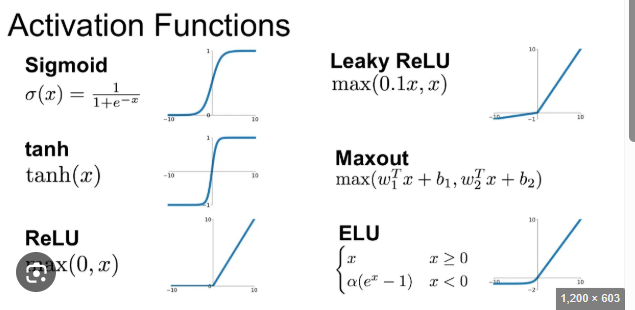

**ReLU**
- max(0,z)
- z가 음수이면 0, 양수이면 그대로 전달
- 역전파
> `z>0`   `dReLU(z)/dz = 1` <br>
> `z<=0`  `dReLU(z)/dz = 0` <br>
- 장점:
    - 비선형 제공 -> 계산이 간단해진다.
    - 기울기 소실이 sigmoid, tanh보다 적다.
    - 음수이면 0 -> 일부 뉴런이 비활성화되어, 표현이 희소해진다. (중요한 애들만 학습만 학습함 => 변형: LeakyReLU)

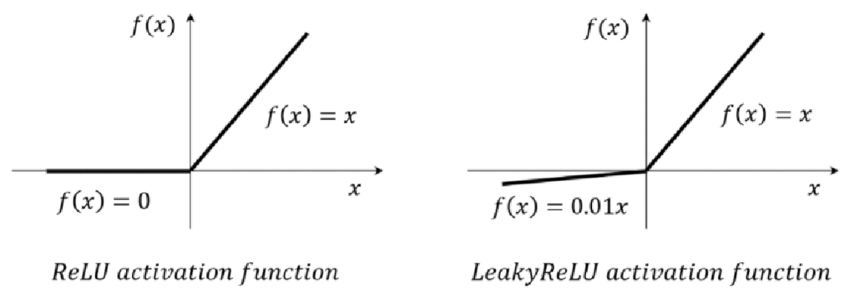

---

##### 옵티마이저
**Adam**
- '모멘텀'과 '스케일 조정'을 결합한 하이브리드 방식
- 적응적 학습률 _파라미터별_ 로 학습률 조정
    - 장점: 초기값이 안정적 & 빠른 수렴(SDG보다 빠르다.) & 튜닝이 거의 필요없음(기본 파라미터 lr=0.001도 좋은 성능)
    - 단점: 과적합이 다른 최적화 모델에 비해 발생하기 쉬운 구조

**Optimezer**: 모델 파라미터의 손실이 줄어들도록 생신하는 역할
- p_t: 현재 파라미터
- n: 학습률
- gt: 현재 gradient

`p_t+1 = p_t - n*gt`

단점: 
- 기울기가 들쑥날쑥함( = noise에 약하다!)
- 모든 파라미터가 같은 학습률을 적용 (why? 각 파라미터마다 중요도가 다른데 -> 비효율적)
=> SOLUTION: 모멘텀, 스케일 조정

##### Momemtum (관성)
https://www.blog.data101.io/382
- 이전 기울기의 방향을 '기억'해 관성처럼 부드럽게 이동하는 기법
- vi: 누적된 속도 or 1차 모멘트
- gt: 현재 gradient
- b1: 모멘텀의 개수(보통 0.5)
- n: 학습률

`vt = b1vt-1 + (1-b1)gt` <br>
     `p_t+1 = p_t - n*vt`

시점
t=1        | 단순히 g1을 따라감  <br>
t=2,       | 이전 속도 v1의 일부를 남겨서 새로운 방향에 더함 <br>
t -> inif  | 여러 스텝동안 방향이 일정하면, 점점 가속되어 빠르게 수렴 <br>

##### 스케일 조정
- 파라미터 기울기의 크기를 고려해, 학습률을 자동으로 조정
- 과거 파라미터의 크기를 추적해 -> 큰 변동이 있었던 파라미터는 작게, 작은 변동은 크게 이동

---

> - Adam
>    - step 1: 모멘텀
>    - step 2: 스케일 조정
>    - step 3: bias 보정, 초기 step에서는 m,v=0임. 이것을 보정
>    - step 4: 최종 업데이트> '모멘텀'으로 얻은 방향 + '스케일 조정'된 학습률

SGD: 단순 gradient => 진동심함, 느림 <br>
Momentum: 과거 방향의 관성 사용 => 진동완화, 빠른수렴 <br>
RMSProp / AdaGrad: gradient제곱의 평균으로 스케일 조정 => 파라미터별 자동 학습률 <br>
Adam: 모멘텀 + RMSProm 결합 => 기본 설정도 훌륭하다.


In [ ]:
# Pytorch
# 미분을 자동으로 계산
# 계산된 미분을 optimizer를 통해 적용 -> 최적화 알고리즘
import torch
import torch.nn as nn 
from torch.optim import Adam

In [54]:
# 1. 모델 정의
model = nn.Sequential(
    nn.Linear(data.shape[1],100), #in: 13개의 데이터(특성)을 입력받아, out: 결과 100개 -> 즉, 100개 예측
    nn.ReLU(),
    nn.Linear(100,1) #100개의 예측결과를 받아, 최종 1개 예측
)

# 2. 하이퍼파라미터 정의
batch_size = 100
learning_rate = 1e-03 #0.001

# 3. 옵티마이저
optim = Adam(model.parameters(), lr=learning_rate)

target = target.reshape(-1,1)

# 4. 학습 루프
for epoch in range(200):
    for i in range(len(data) // batch_size):    #506//100 = 5
        start = i*batch_size
        end = start + batch_size
        X = torch.FloatTensor(data[start:end])
        y = torch.FloatTensor(target[start:end])

        optim.zero_grad() #학습 이후 다음 학습에 이전 가중치가 계산되는 것을 방지
        preds = model(X) #forward, 입력과 출력의 shape가 같아야함.!!
        loss = nn.MSELoss()(preds,y)  #__call__ 자동호출, preds과 정답의 shape가 같아야함.
        loss.backward() #backward: 기울기 계산, 각 파라미터의 gradient를 자동으로 계산 -> 내부적으로 .grad에 저장
        optim.step() #업데이트: .optimizer가 .grad의 정보를 사용해 파라미터를 갱신

    if epoch % 20 == 0:
        print(f'epoch: {epoch+1} | loss: {loss.item()}') #epoch의 가장 마지막 batch만 출력(평균)



epoch: 1 | loss: 137.46420288085938
epoch: 21 | loss: 20.097335815429688
epoch: 41 | loss: 17.544126510620117
epoch: 61 | loss: 16.035676956176758
epoch: 81 | loss: 14.943570137023926
epoch: 101 | loss: 14.123723983764648
epoch: 121 | loss: 13.283782958984375
epoch: 141 | loss: 12.836932182312012
epoch: 161 | loss: 12.15913200378418
epoch: 181 | loss: 20.864187240600586


In [ ]:
# 5. 모델 성능 평가: 예측
print(data.shape, target.shape)
predict = model(torch.FloatTensor(data[0])).item()
predict, target[0].item() #예측값과 실제정답

(506, 13) (506, 1)


(30.65057945251465, 24.0)

In [57]:
predict = model(torch.FloatTensor(data)).detach().numpy()
predict.shape, target.shape

((506, 1), (506, 1))

In [58]:
from sklearn.metrics import r2_score

r2_score(target, predict)

0.7185275464946476

In [75]:
# 적절한 머신러닝 알고리즘으로 비교 평가
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 분리
X_train,X_test,y_train,y_test = train_test_split(data,target, test_size=0.2, random_state=42)

# 2. 분리한 데이터 텐서 변환
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1,1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1,1)


with torch.no_grad():
    pred_torch = model(X_test_t) #텐서로 변환한 데이터 사용
mse_torch = mean_squared_error(y_test, pred_torch.numpy())
r2_torch = r2_score(y_test, pred_torch.numpy())

mse_torch, r2_torch


(20.14081457982608, 0.7253542131353832)

In [77]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train.ravel()) #텐서로 변환하지 않은 데이터 사용!!
pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

mse_rf, r2_rf

(7.901513892156864, 0.8922527442109116)